<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [ ]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import json
from PIL import Image
import seaborn as sns
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils
import scipy.sparse as sp
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import squidpy as sq

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWar

# Spatial

In [3]:
dataset_name = "merfish_mouse_brain"  # options: visium_human_mouse, merfish_mouse_brain
resolution = "008um"  # options: 002um, 008um, 016um, etc
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 16  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "visium_human_mouse":
    binned_outputs_url = "https://cf.10xgenomics.com/samples/spatial-exp/4.0.1/Visium_HD_3prime_Human_Mouse_Xenograft/Visium_HD_3prime_Human_Mouse_Xenograft_binned_outputs.tar.gz"  # https://www.10xgenomics.com/datasets/visium-hd-three-prime-human-mouse-xenograft-fresh-frozen
    expected_cells = 250_000
    leiden_resolution = 1.0
    technology = "visium_hd"
elif dataset_name == "merfish_mouse_brain":
    adata_url = "https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/expression_matrices/Zhuang-ABCA-2/20230830/Zhuang-ABCA-2-raw.h5ad"  # https://alleninstitute.github.io/abc_atlas_access/descriptions/Zhuang-ABCA-2.html
    cell_metadata_url = "https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/metadata/Zhuang-ABCA-2/20241115/views/cell_metadata_with_cluster_annotation.csv"
    ccf_coordinates_url = "https://allen-brain-cell-atlas.s3-us-west-2.amazonaws.com/metadata/Zhuang-ABCA-2-CCF/20230830/ccf_coordinates.csv"
    example_section = "Zhuang-ABCA-2.037"
    expected_cells = None
    leiden_resolution = 1.0
    technology = "merfish"
else:
    raise ValueError(f"Unknown dataset_name: {dataset_name}")

if technology == "visium_hd":
    binned_outputs_dir = f"{data_dir}/binned_outputs"
    if not os.path.exists(binned_outputs_dir):
        !wget -O {binned_outputs_dir}.tar.gz {binned_outputs_url}
        !tar -xvzf {binned_outputs_dir}.tar.gz -C {data_dir}
    matrix_dir_raw = os.path.join(binned_outputs_dir, f"square_{resolution}")
elif technology == "merfish":
    adata_raw_path = os.path.join(data_dir, "Zhuang-ABCA-2-raw.h5ad")
    if not os.path.exists(adata_raw_path):
        !wget -O {adata_raw_path} {adata_url}
    cell_metadata_path = os.path.join(data_dir, "_with_cluster_annotation.csv")
    if not os.path.exists(cell_metadata_path):
        !wget -O {cell_metadata_path} {cell_metadata_url}
    # matrix_dir_raw = os.path.join(binned_outputs_dir, f"square_{resolution}")
else:
    raise ValueError(f"Unknown technology: {technology}")

adata_path_cellsweep = os.path.join(data_dir, "adata_cellsweep.h5ad")
cellsweep_log_file = os.path.join(data_dir, "cellsweep.log")

## Knee plot - use this output to estimate umi_cutoff

In [20]:
if technology == "visium_hd":
    adata_raw = cs_utils.load_adata(os.path.join(matrix_dir_raw, "raw_feature_bc_matrix.h5"))
    adata_raw.var_names_make_unique()

    spatial_df = pd.read_parquet(os.path.join(matrix_dir_raw, "spatial", "tissue_positions.parquet"))
    adata_raw.obs = adata_raw.obs.merge(spatial_df.set_index("barcode"), left_index=True, right_index=True, how="left")
    adata_raw.obsm["spatial"] = adata_raw.obs[["pxl_col_in_fullres", "pxl_row_in_fullres"]].to_numpy()

    spatial_dir = f"{matrix_dir_raw}/spatial"
    with open(f"{spatial_dir}/scalefactors_json.json") as f:
        scalefactors = json.load(f)

    adata_raw.uns["spatial"] = {
        "square_008um": {
            "images": {
                "hires": np.array(Image.open(f"{spatial_dir}/tissue_hires_image.png")),
                "lowres": np.array(Image.open(f"{spatial_dir}/tissue_lowres_image.png")),
            },
            "scalefactors": scalefactors,
        }
    }

elif technology == "merfish":
    adata_raw = ad.read_h5ad(adata_raw_path)
    adata_raw.X = sp.csr_matrix(adata_raw.X)
    meta_df = pd.read_csv(cell_metadata_path, index_col=0)
    meta_df = meta_df.drop(columns=["brain_section_label"])  # already in adata_raw.obs
    adata_raw = adata_raw[adata_raw.obs_names.isin(meta_df.index)].copy()
    adata_raw.obs = adata_raw.obs.join(meta_df, how="left")

else:
    raise ValueError(f"Unknown technology: {technology}")

In [21]:
adata_raw

AnnData object with n_obs × n_vars = 1227408 × 1122
    obs: 'brain_section_label', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'cluster_alias', 'x', 'y', 'z', 'subclass_confidence_score', 'cluster_confidence_score', 'high_quality_transfer', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color'
    var: 'gene_symbol'

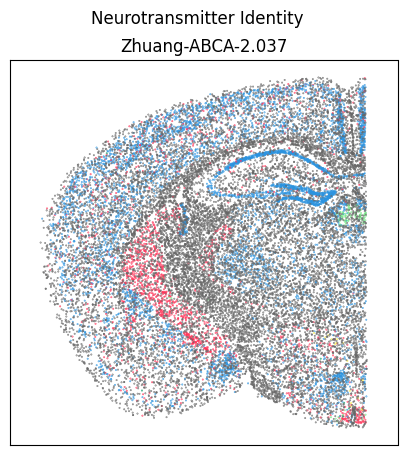

In [22]:
if technology == "visium_hd":
    sq.pl.spatial_scatter(adata_raw)
elif technology == "merfish":
    _ = cs_utils.plot_merfish(adata_raw, example_section=example_section, cc='neurotransmitter_color', suptitle = 'Neurotransmitter Identity')

UMI cutoff for expected cells (1100000): 47.00


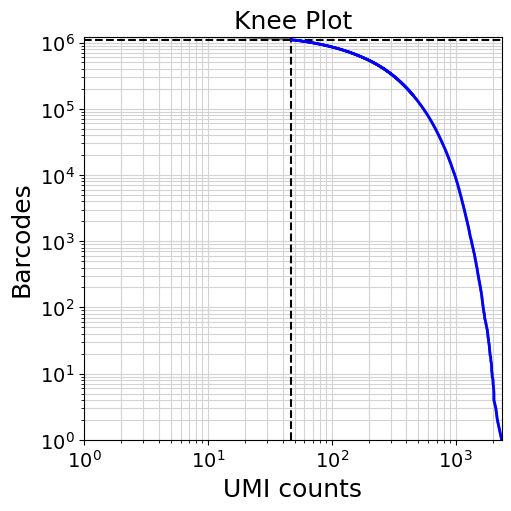

In [23]:
if technology == "visium_hd":
    expected_cells = 250_000
elif technology == "merfish":
    expected_cells = 1_100_000
else:
    expected_cells = None

umi_cutoff = cs_utils.knee_plot(adata_raw, transpose=True, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [24]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
if "in_tissue" in adata_raw.obs.columns:
    adata_raw.obs['is_empty'] = (adata_raw.obs['is_empty'] | (~adata_raw.obs['in_tissue'].fillna(False).astype(bool)))
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

if "in_tissue" in adata_raw.obs.columns:
    print(f"Empty and in tissue: {len(adata_raw.obs.loc[(adata_raw.obs['is_empty']) & (adata_raw.obs['in_tissue'])])}")
    print(f"Empty and not in tissue: {len(adata_raw.obs.loc[(adata_raw.obs['is_empty']) & (~adata_raw.obs['in_tissue'])])}")
    print(f"Not empty and in tissue: {len(adata_raw.obs.loc[(~adata_raw.obs['is_empty']) & (adata_raw.obs['in_tissue'])])}")
    # print(f"Not empty and not in tissue: {len(adata_raw.obs.loc[(~adata_raw.obs['is_empty']) & (~adata_raw.obs['in_tissue'])])}")  # 0 (as enforced above)

## cellsweep

In [64]:
if not os.path.exists(adata_path_cellsweep) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata_raw.obs.columns:
        adata_processed_tmp = adata_raw[~adata_raw.obs["is_empty"]].copy()
        adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
        adata_raw.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata_raw.obs.index).astype(str).replace("nan", "empty").astype("category")
    adata_cellsweep = denoise_count_matrix(adata_raw, init_alpha=0.9, beta=0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
else:
    adata_cellsweep = cs_utils.load_adata(adata_path_cellsweep, verbose=verbose)

adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep.var_names_make_unique()

22:59:13 - INFO - Adata initial shape: (1101836, 1122)
22:59:13 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
22:59:14 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
22:59:14 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like c

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/merfish_mouse_brain/cellsweep.log


23:07:22 - INFO - Number of celltypes: 45
23:07:22 - INFO - Inferring celltype profiles.
23:07:23 - DEBUG - Number of parameters in the cellsweep model: 1,152,327 (alpha: 1,101,836, beta: 1, p_k: 50,490)
23:07:23 - INFO - Inferring the gene ambient profile from empty droplets.
23:07:23 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
23:07:24 - INFO - Performing Sparse EM with 16 Numba thread(s)
23:07:37 - INFO - EM Iter   1: ll=-1439.615 log_delta_p=inf min_alpha=0.2619 mean_alpha=0.7144 median_alpha=0.7278 max_alpha=0.9000 beta=0.116611
23:07:37 - DEBUG - 399 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
23:07:46 - INFO - EM Iter   2: ll=-1334.372 log_delta_p=inf min_alpha=0.0355 mean_alpha=0.4981 median_alpha=0.4949 max_alpha=0.9000 beta=0.103482
23:07:46 - DEBUG - 247 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-typ

## Analysis

### Raw vs cellsweep knee plot, scatterplots

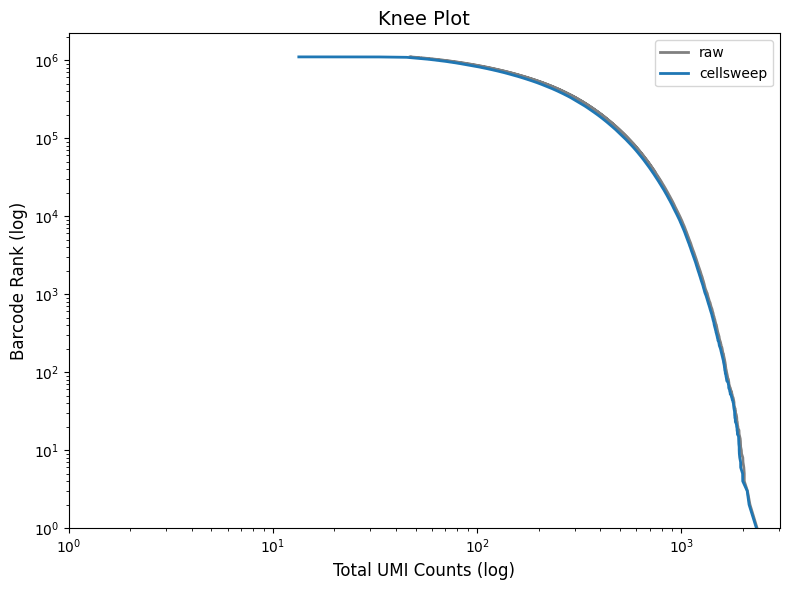

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


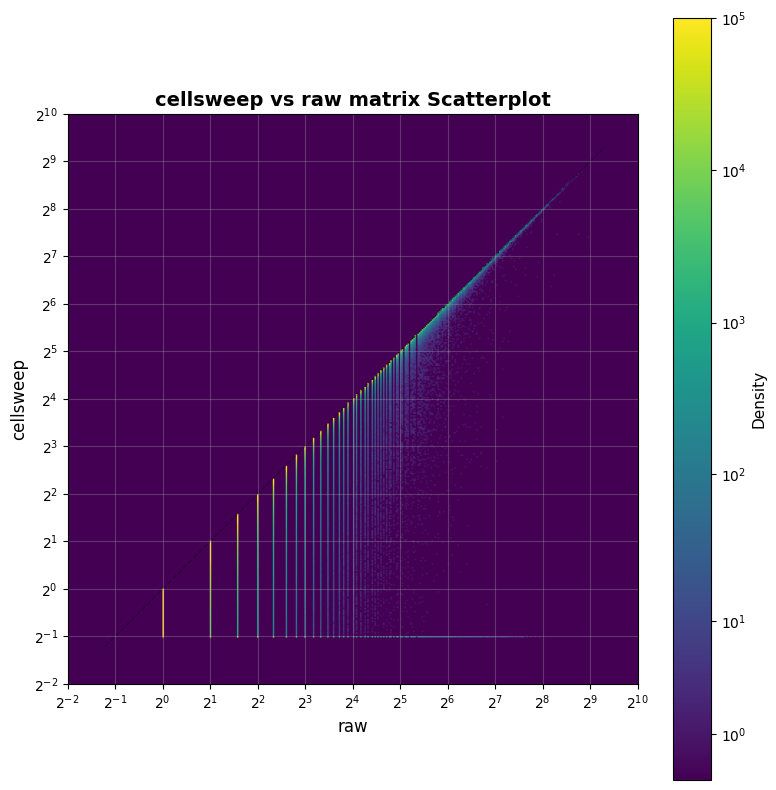

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


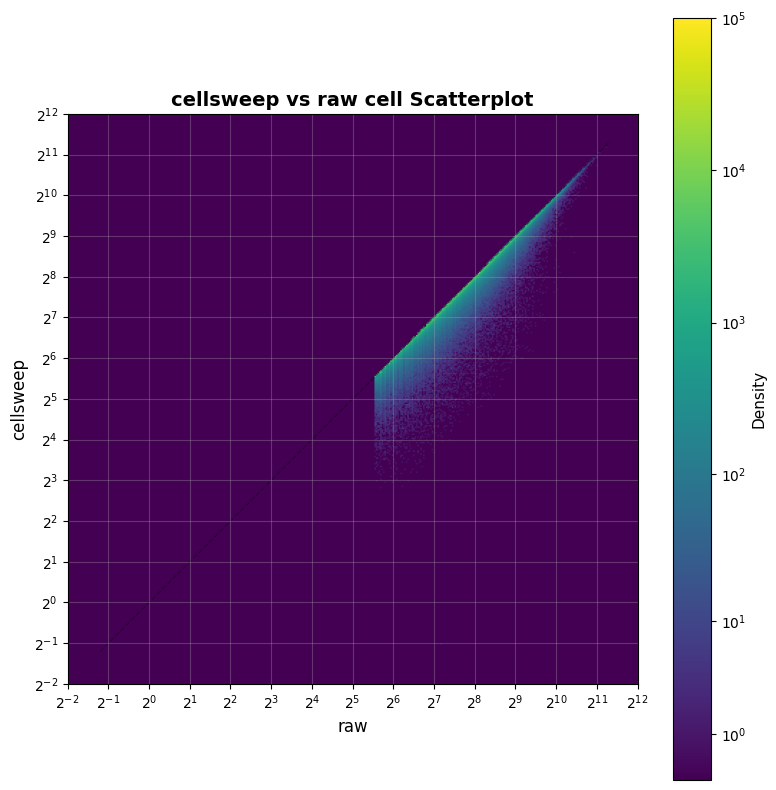

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


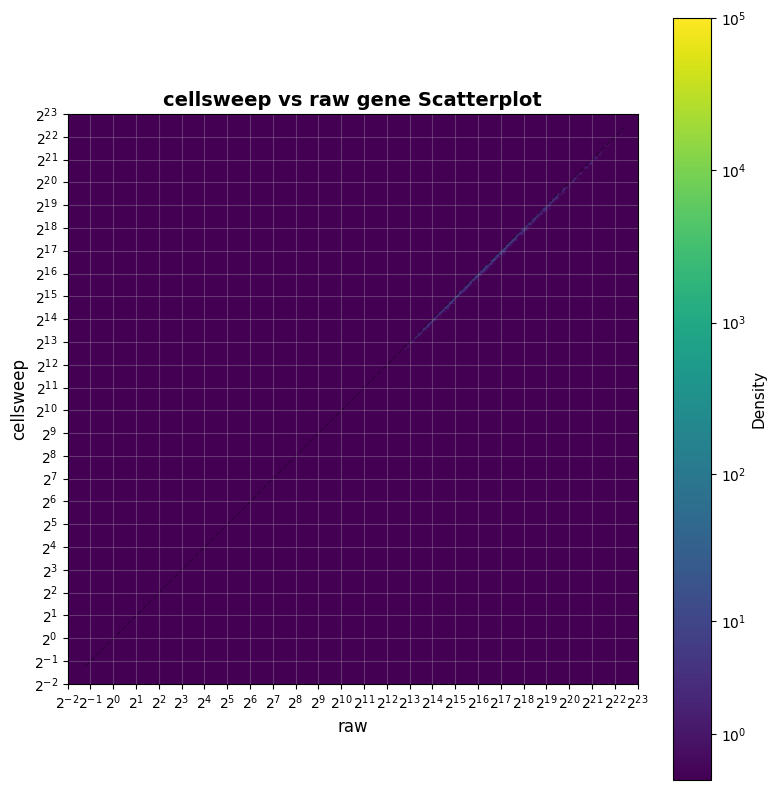

In [65]:
cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title="Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, "cellsweep_knee_plot.png"))

cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, "matrix_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, "cell_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, "gene_expression_scatterplot.png"), show=True)

## Spatial localization of alpha_hat

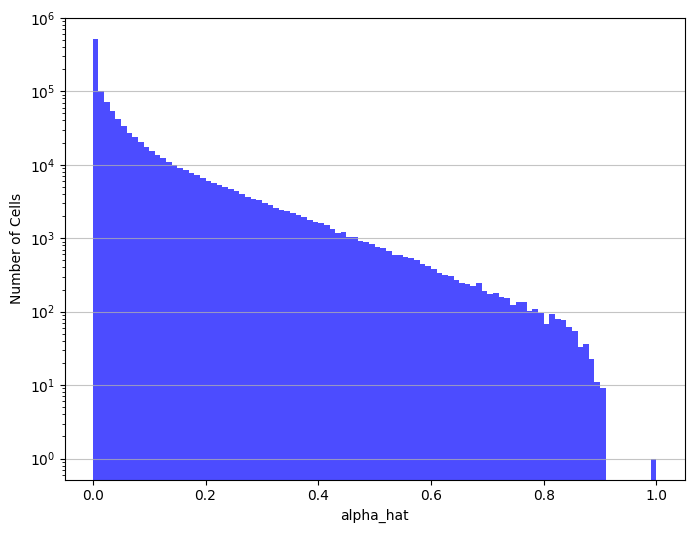

In [66]:
cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(out_dir, "alpha_hat_histogram.png"), ylog=True)

In [67]:
# make alpha_hat bins - 0-0.25, 0.25-0.5, 0.5-0.75, 0.75-1.0
bins = [0, 0.25, 0.5, 0.75, 1.0]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
adata_cellsweep.obs['alpha_hat_bin'] = pd.cut(adata_cellsweep.obs['alpha_hat'], bins=bins, labels=labels)
if technology == "merfish":
    adata_cellsweep.obs['alpha_hat_bin_color'] = pd.cut(adata_cellsweep.obs['alpha_hat'], bins=bins, labels=sns.color_palette("tab20", n_colors=len(labels)).as_hex())
    value_to_color = dict(zip(adata_cellsweep.obs['alpha_hat_bin'].cat.categories.astype(str), adata_cellsweep.obs['alpha_hat_bin_color'].cat.categories.astype(str)))

In [68]:
adata_cellsweep.obs.head()

,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,...,subclass_color,supertype_color,cluster_color,is_empty,celltype,cell_ambient_fraction,alpha_hat,z_hat,alpha_hat_bin,alpha_hat_bin_color
cell_label,,,,,,,,,,,,,,,,,,,,,
234935021349889588272390626853122325011,Zhuang-ABCA-2.035,Zhuang-ABCA-2,Zhuang-ABCA-2,wt/wt,M,175,3.486825,5.613528,6.386148,0.999989,...,#3DCCB7,#3B9900,#4A662E,False,0,0.9,1.739588e-01,1,0-0.25,#1f77b4
167661822891342906039179419220149588845,Zhuang-ABCA-2.035,Zhuang-ABCA-2,Zhuang-ABCA-2,wt/wt,M,188,1.712171,4.699509,6.386148,0.836114,...,#3DCCB7,#009909,#99E4FF,False,3,0.9,2.231717e-02,24,0-0.25,#1f77b4
180748436217436888836427253669665415757,Zhuang-ABCA-2.035,Zhuang-ABCA-2,Zhuang-ABCA-2,wt/wt,M,182,1.710260,4.776539,6.386148,0.873162,...,#3DCCB7,#3B9900,#955CCC,False,3,0.9,1.798630e-02,24,0-0.25,#1f77b4
39715304353385421101480591568727848940,Zhuang-ABCA-2.035,Zhuang-ABCA-2,Zhuang-ABCA-2,wt/wt,M,182,1.735593,4.735995,6.386148,0.803502,...,#3DCCB7,#3B9900,#955CCC,False,3,0.9,4.008809e-02,24,0-0.25,#1f77b4
227642604501555508392258462232575207516,Zhuang-ABCA-2.035,Zhuang-ABCA-2,Zhuang-ABCA-2,wt/wt,M,188,2.483692,4.766999,6.386148,0.984064,...,#3DCCB7,#009909,#99E4FF,False,3,0.9,1.092607e-07,24,0-0.25,#1f77b4


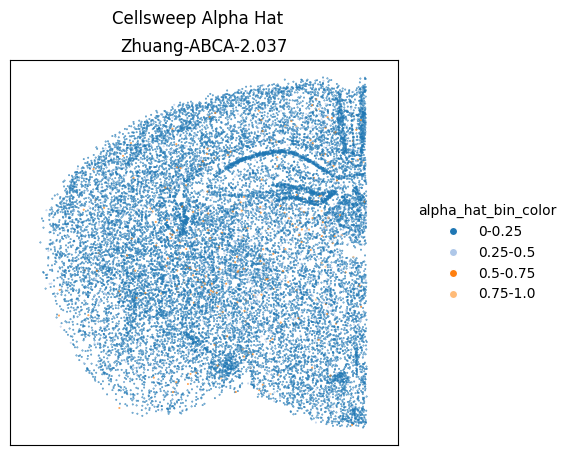

In [69]:
if technology == "visium_hd":
    sq.pl.spatial_scatter(adata_cellsweep, color="alpha_hat_bin", size=4, palette="viridis")
elif technology == "merfish":
    _ = cs_utils.plot_merfish(adata_cellsweep, example_section=example_section, cc='alpha_hat_bin_color', suptitle = 'Cellsweep Alpha Hat', value_to_color=value_to_color)

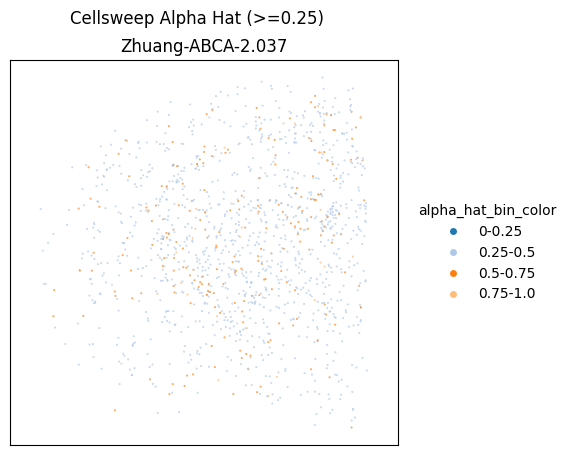

In [70]:
if technology == "visium_hd":
    sq.pl.spatial_scatter(adata_cellsweep[adata_cellsweep.obs["alpha_hat"] >= 0.25], color="alpha_hat_bin", size=4, palette="viridis")
elif technology == "merfish":
    _ = cs_utils.plot_merfish(adata_cellsweep[adata_cellsweep.obs["alpha_hat"] >= 0.25], example_section=example_section, cc='alpha_hat_bin_color', suptitle = 'Cellsweep Alpha Hat (>=0.25)', value_to_color=value_to_color)

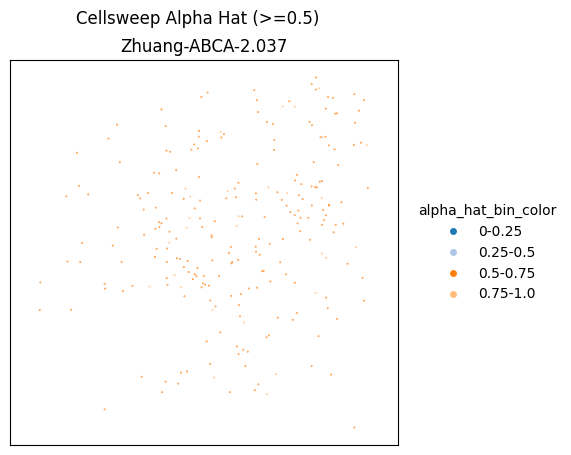

In [71]:
if technology == "visium_hd":
    sq.pl.spatial_scatter(adata_cellsweep[adata_cellsweep.obs["alpha_hat"] >= 0.5], color="alpha_hat_bin", size=4, palette="viridis")
elif technology == "merfish":
    _ = cs_utils.plot_merfish(adata_cellsweep[adata_cellsweep.obs["alpha_hat"] >= 0.5], example_section=example_section, cc='alpha_hat_bin_color', suptitle = 'Cellsweep Alpha Hat (>=0.5)', value_to_color=value_to_color)

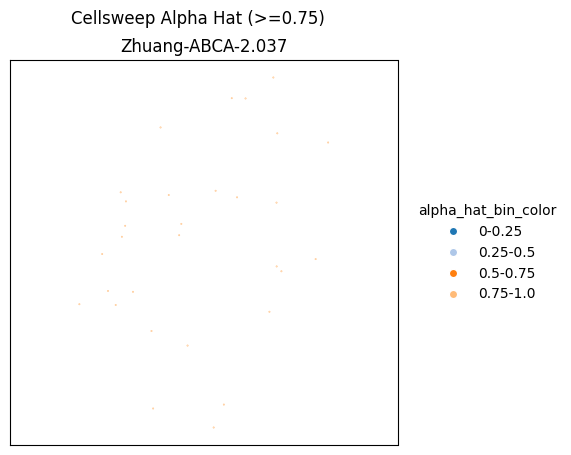

In [72]:
if technology == "visium_hd":
    sq.pl.spatial_scatter(adata_cellsweep[adata_cellsweep.obs["alpha_hat"] >= 0.75], color="alpha_hat_bin", size=4, palette="viridis")
elif technology == "merfish":
    _ = cs_utils.plot_merfish(adata_cellsweep[adata_cellsweep.obs["alpha_hat"] >= 0.75], example_section=example_section, cc='alpha_hat_bin_color', suptitle = 'Cellsweep Alpha Hat (>=0.75)', value_to_color=value_to_color)

In [73]:
if technology == "visium_hd":
    sq.gr.spatial_neighbors(adata_cellsweep)
    sq.gr.nhood_enrichment(adata_cellsweep, cluster_key="alpha_hat_bin")
    sq.pl.nhood_enrichment(adata_cellsweep, cluster_key="alpha_hat_bin")

In [74]:
if technology == "visium_hd":
    sq.gr.spatial_autocorr(
        adata_cellsweep,
        mode="moran",
        genes="alpha_hat",
        attr="obs",
        n_jobs=threads,
        seed=42
    )
    adata_cellsweep.uns["moranI"]

In [75]:
# adata_raw_original = adata_raw.copy()
# adata_cellsweep_original = adata_cellsweep.copy()

In [76]:
if dataset_name == "visium_human_mouse":
    def identify_human_and_mouse_cells_here(adata):
        if "human_counts_total_" in adata.obs.columns and "mouse_counts_total_" in adata.obs.columns and "genome" in adata.obs.columns:
            return adata  # already identified
        
        is_human = (adata.var["genome"] == "GRCh38").values
        is_mouse = (adata.var["genome"] == "GRCm39").values
        adata.obs["human_counts_total_"] = np.array(adata.X[:, is_human].sum(axis=1)).ravel()
        adata.obs["mouse_counts_total_"] = np.array(adata.X[:, is_mouse].sum(axis=1)).ravel()
        adata.obs['genome'] = np.where(adata.obs['human_counts_total_'] >= adata.obs['mouse_counts_total_'], 'human', 'mouse')  # predict genome
        return adata
    
    # adata_raw = adata_raw_original.copy()
    # adata_cellsweep = adata_cellsweep_original.copy()
    
    # np.random.seed(0)
    # adata_raw = adata_raw[np.random.choice(adata_raw.shape[0], 10000, replace=False)]

    adata_raw = identify_human_and_mouse_cells_here(adata_raw)
    adata_cellsweep = identify_human_and_mouse_cells_here(adata_cellsweep)

    adata_raw.obs["total_counts"] = adata_raw.obs["human_counts_total_"] + adata_raw.obs["mouse_counts_total_"]
    adata_raw.obs["frac_human"] = adata_raw.obs["human_counts_total_"] / adata_raw.obs["total_counts"]
    adata_raw.obs["frac_mouse"] = 1 - adata_raw.obs["frac_human"]
    fraction_doublet = 0.10
    adata_raw.obs["is_doublet"] = (adata_raw.obs["frac_human"] > fraction_doublet) & (adata_raw.obs["frac_human"] < (1 - fraction_doublet))
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()

    cs_utils.plot_cross_species_joint_scatterplot(adata_raw_no_doublets, adata_cellsweep, processed_name="cellsweep", x_name="human", y_name="mouse", x_axis="human_counts_total_", y_axis="mouse_counts_total_", genome_column="genome", marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, "visium_human_mouse_cellsweep_joint_scatterplot.png"), show=True)